
# Trader Performance vs Market Sentiment
## Data Science Intern Assignment


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")


## 1. Data Loading
We load Bitcoin Fear-Greed sentiment data and Hyperliquid historical trader data.


In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
sentiment.shape
trades.shape
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)



Sentiment shape: (2644, 5)
Trades shape: (211224, 17)


Sentiment dataset contains 2,644 rows and 5 columns.
Trader dataset contains 211,224 rows and 17 columns.


In [3]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Cleaning and Preparation
We standardize column names, convert timestamps into dates, and merge both datasets on daily level.


In [4]:
sentiment.columns


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [5]:
sentiment["Classification"] = sentiment["classification"]
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date


In [6]:
sentiment[["date","Classification"]].head()


,date,Classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [8]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

trades["date"] = trades["Timestamp IST"].dt.date


In [9]:
trades[["Timestamp IST","date"]].head()


,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [10]:
merged = trades.merge(
    sentiment[["date","Classification"]],
    on="date",
    how="left"
)

merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [11]:
merged["Classification"].value_counts()


Classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

## Sentiment Distribution

Fear and Greed categories dominate the dataset, while Extreme Fear has the lowest number of observations.


## 3. Exploratory Data Analysis (EDA)

In this section, we explore how trader performance varies across different market sentiment regimes using summary statistics and visualizations.


In [12]:
merged.groupby("Classification")["Closed PnL"].mean()


Classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

### Insight 1 : Average PnL vs Sentiment

Traders earn the highest average PnL during Extreme Greed days, 
while Extreme Fear and Neutral days show comparatively lower profitability.


In [13]:
merged["win"] = merged["Closed PnL"] > 0
merged.groupby("Classification")["win"].mean()


Classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

### Insight 2: Win Rate vs Sentiment

Win rate is highest during Extreme Greed days and lowest during Extreme Fear days,
indicating directional markets improve trade accuracy.


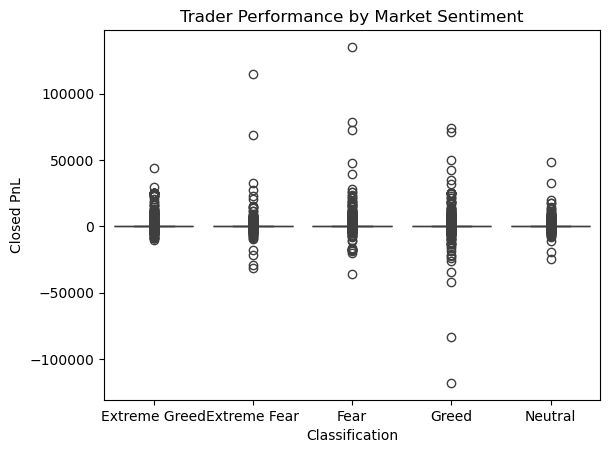

In [14]:
sns.boxplot(
    data=merged,
    x="Classification",
    y="Closed PnL"
)
plt.title("Trader Performance by Market Sentiment")
plt.show()


### Insight 3: Volatility Across Sentiment

Higher PnL volatility is observed during Extreme Fear and Greed regimes, indicating increased risk during emotionally driven market conditions.



In [21]:
merged.groupby("Classification")["Closed PnL"].std()


Classification
Extreme Fear     1136.056091
Extreme Greed     766.828294
Fear              935.355438
Greed            1116.028390
Neutral           517.122220
Name: Closed PnL, dtype: float64

## 4. Trader Behavior vs Sentiment
We analyze how trading activity and position size change across sentiment regimes.



In [22]:
merged.groupby("Classification")["Size USD"].mean()



Classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [23]:
merged.groupby("Classification").size()


Classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

### Insight 4: Trading Activity vs Sentiment

Trading activity is highest during Fear days and lowest during Extreme Fear days,
suggesting traders become more active in volatile but not panic conditions.


### Insight 5: Position Size vs Sentiment

Average position size is highest during Fear and Greed regimes, indicating traders deploy larger capital when markets are volatile and offer higher opportunity, while Extreme Greed shows relatively smaller average position sizes.

## 5. Actionable Strategy Ideas

1. During Extreme Fear days, reduce trading frequency and position size to control risk.
2. During Extreme Greed days, allow larger position sizes but with strict risk limits.


### Conclusion

This analysis demonstrates that market sentiment significantly influences trader profitability, win rate, risk, and behavior. Fear-driven markets exhibit higher trading activity and larger position sizes, while Extreme Greed phases show the highest average profitability. These findings highlight the importance of sentiment-aware risk management and adaptive position sizing strategies